<a href="https://colab.research.google.com/github/PabloDuranL/Miprogresionypraticas/blob/main/Incidentes_viales_CMDX_C5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación Binaria: Incidentes Viales CDMX (C5)

**Fuente:** Portal de Datos Abiertos de la Ciudad de México — Centro de Comando C5
**URL:** https://datos.cdmx.gob.mx/dataset/incidentes-viales-c5
**Descripción:** Registro de incidentes viales desde 2014, actualizado mensualmente. Incluye: folio, fecha/hora de creación y cierre, motivo del incidente, alcaldía, latitud/longitud, código de cierre, clasificación, y origen del incidente.

**Variable respuesta (a construir):** `requirio_despacho` — binaria, indica si el incidente generó despacho de unidad de emergencia (código de cierre `A = Afirmativo`) o no (`N, F, D`).

**Motivación:** Modelar la probabilidad de despacho permite estimar la demanda de recursos de emergencia y calcular tarifas de seguros de responsabilidad civil vial. El desbalance de clases es pronunciado y obliga a decisiones metodológicas cuidadosas.

**Reto técnico:** desbalance de clases, variables temporales, coordenadas geoespaciales, categorías con alta cardinalidad (motivo del incidente).



# Objetivo

Predecir la probabilidad de que un incidente vial requiera despacho de una unidad de emergencia.

Variable objetivo:

Y={1 si codigo_cierre= A
  y 0 otro caso
	​

¿Qué varibles del incidente explican o permiten anticipar la necesidad de despacho?

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)
import matplotlib.pyplot as plt


In [ ]:
df = pd.read_csv(
    "inViales_completa.csv"
)


In [ ]:
df.info()
df.describe()
df.tail()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2115080 entries, 0 to 2115079
Data columns (total 17 columns):
 #   Column             Dtype  
---  ------             -----  
 0   folio              object 
 1   fecha_creacion     object 
 2   hora_creacion      object 
 3   dia_semana         object 
 4   fecha_cierre       object 
 5   hora_cierre        object 
 6   tipo_incidente_c4  object 
 7   incidente_c4       object 
 8   alcaldia_inicio    object 
 9   codigo_cierre      object 
 10  clas_con_f_alarma  object 
 11  tipo_entrada       object 
 12  alcaldia_cierre    object 
 13  alcaldia_catalogo  object 
 14  colonia_catalogo   object 
 15  longitud           float64
 16  latitud            float64
dtypes: float64(2), object(15)
memory usage: 274.3+ MB


,folio,fecha_creacion,hora_creacion,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,alcaldia_cierre,alcaldia_catalogo,colonia_catalogo,longitud,latitud
2115075,C5/20240229/04009,2024-02-29,19:53:36,Jueves,2024-02-29,23:16:21,Accidente,Choque con lesionados,IZTAPALAPA,A,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,El Vergel,-99.087270,19.320600
2115076,C5/20240229/04038,2024-02-29,20:01:42,Jueves,2024-02-29,23:06:17,Accidente,Choque con lesionados,CUAUHTEMOC,A,URGENCIAS MEDICAS,RADIO,CUAUHTEMOC,Cuauhtémoc,Centro,-99.125200,19.428723
2115077,C5/20240229/04286,2024-02-29,20:43:20,Jueves,2024-02-29,23:46:22,Accidente,Choque con lesionados,IZTAPALAPA,D,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Apatlaco,-99.119881,19.380011
2115078,C5/20240229/04300,2024-02-29,20:46:18,Jueves,2024-02-29,23:56:17,Accidente,Motociclista,IZTAPALAPA,F,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Guadalupe Del Moral,-99.080981,19.369412
2115079,C5/20240229/04349,2024-02-29,20:53:56,Jueves,2024-02-29,23:58:48,Accidente,Choque sin lesionados,IZTAPALAPA,A,EMERGENCIA,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Juan Escutia,-99.054112,19.397305


## Analisis Exploratorio de los Datos

In [ ]:
cat_vars = [
    "dia_semana",
    "tipo_incidente_c4",
    "incidente_c4",
    "alcaldia_inicio",
    "codigo_cierre",
    "clas_con_f_alarma",
    "tipo_entrada",
    "alcaldia_cierre",
    "alcaldia_catalogo"
]

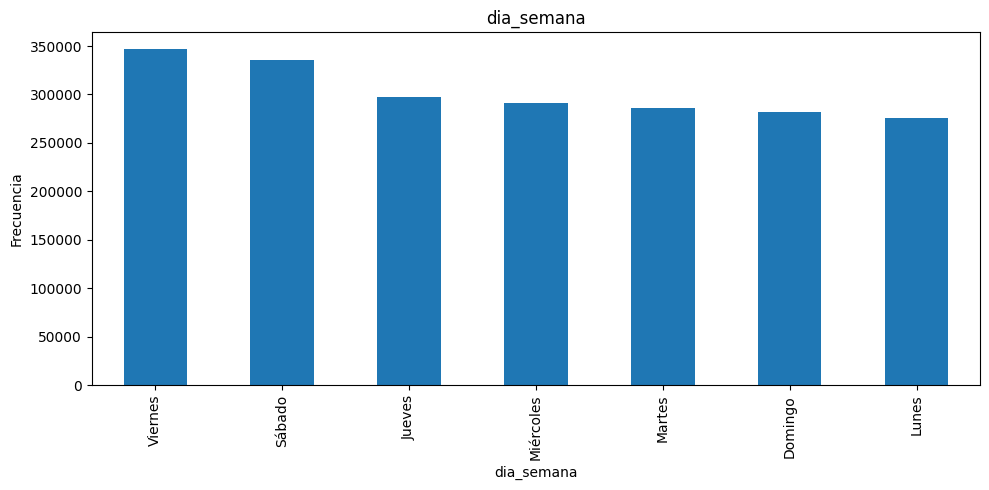

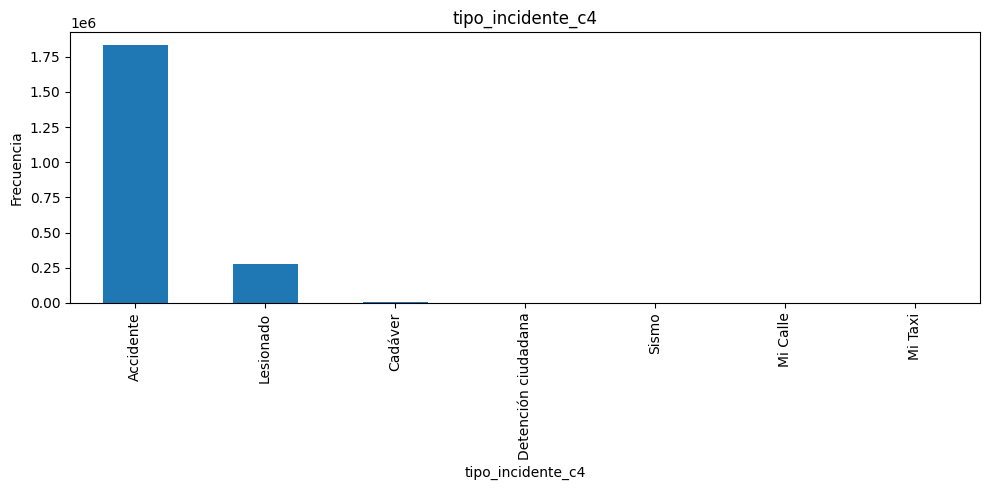

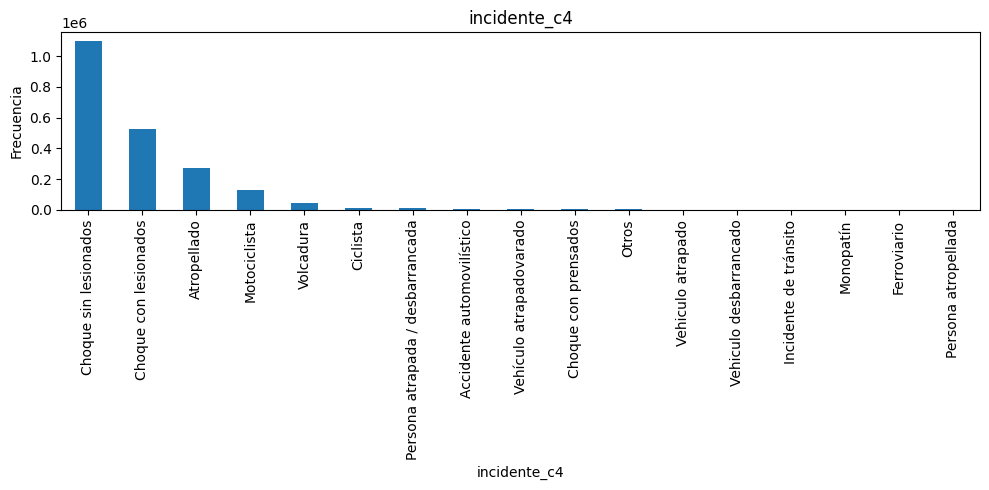

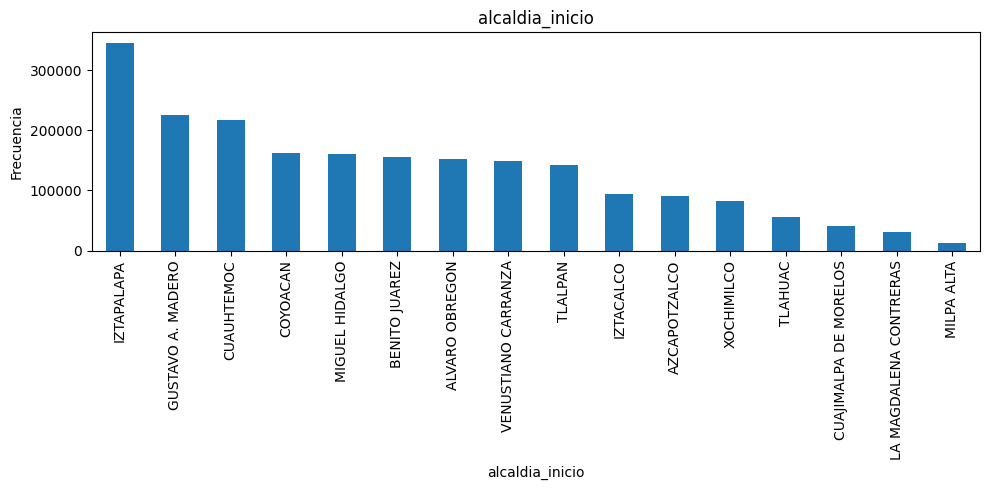

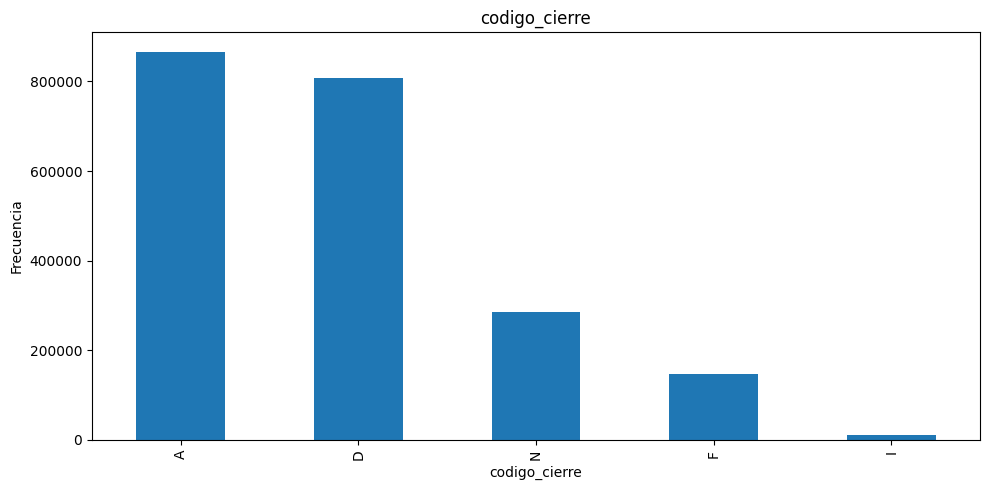

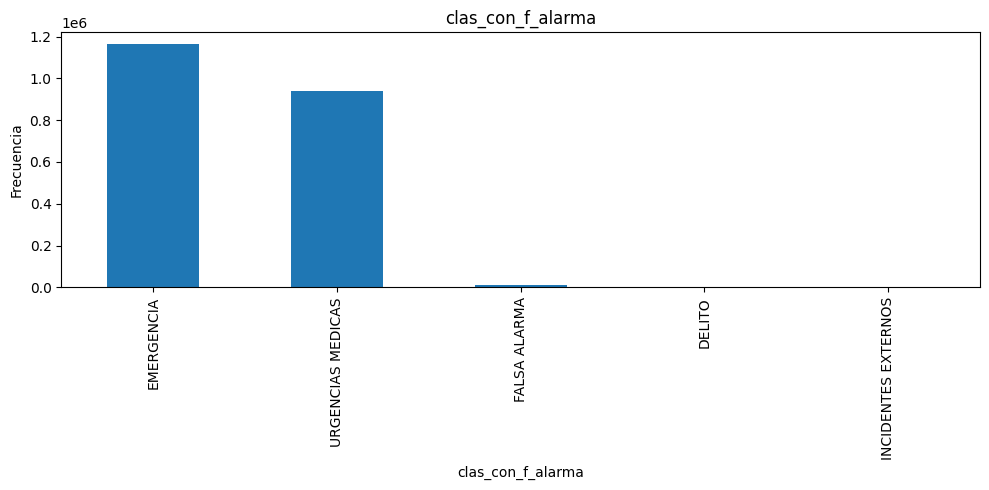

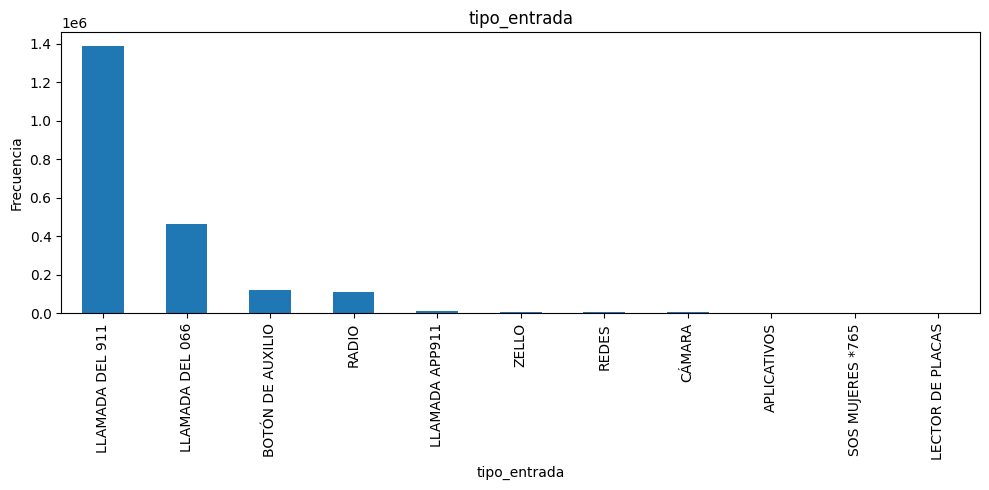

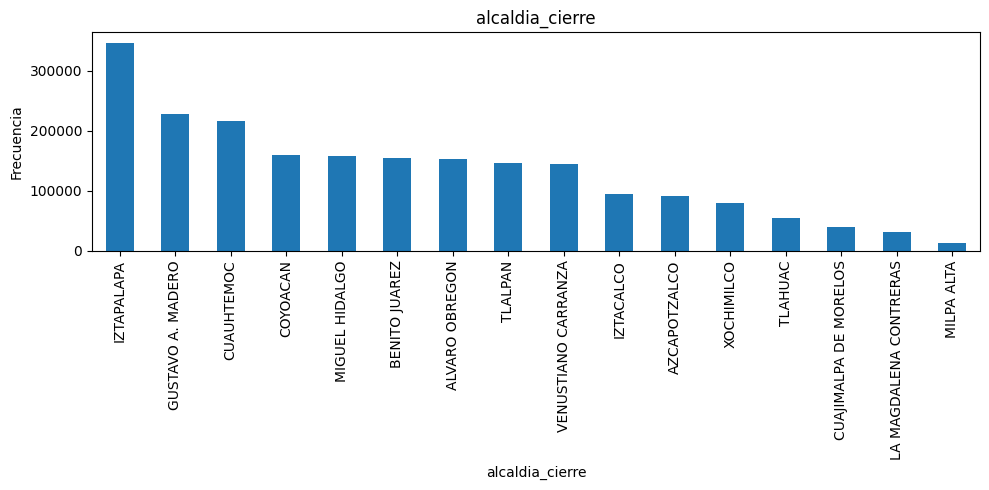

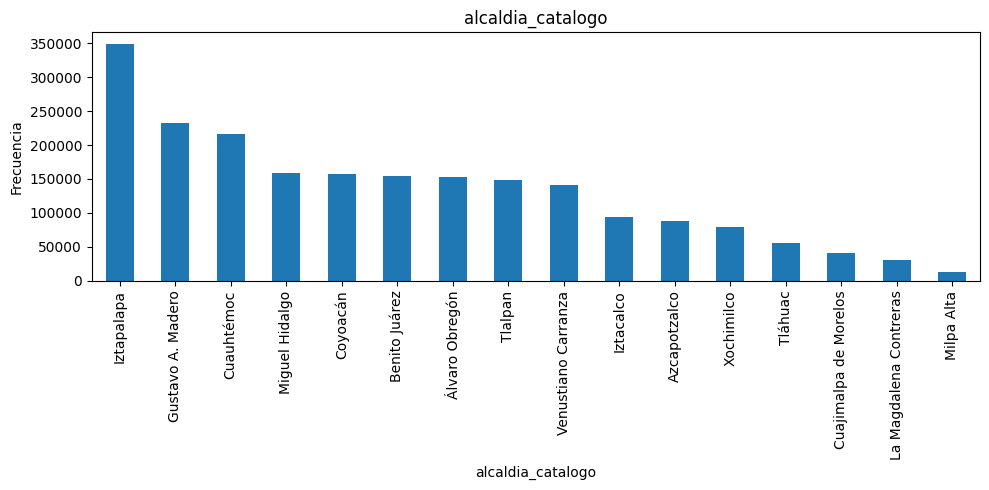

In [ ]:
for col in cat_vars:

    plt.figure(figsize=(10,5))

    df[col].value_counts().head(20).plot(
        kind="bar"
    )

    plt.title(col)
    plt.ylabel("Frecuencia")
    plt.tight_layout()

    plt.show()

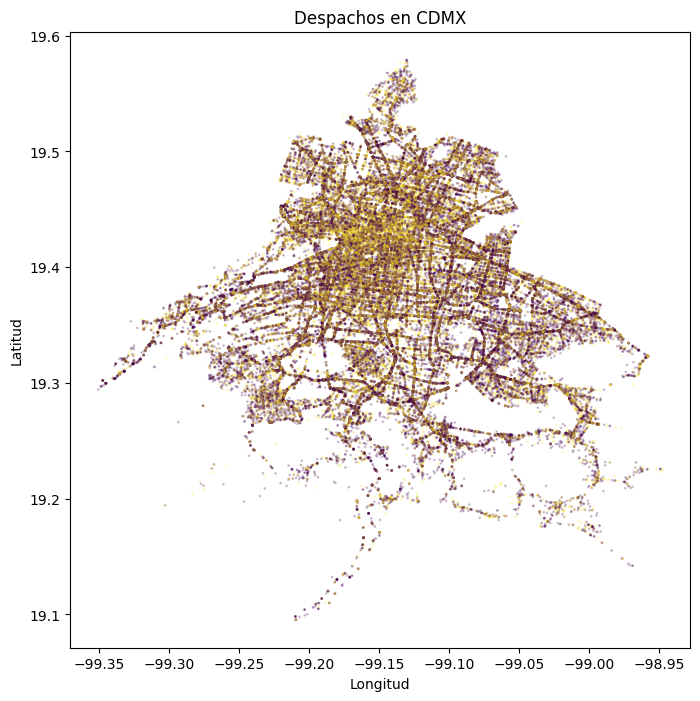

In [ ]:
muestra = df.sample(100000, random_state=42)

plt.figure(figsize=(8,8))

plt.scatter(
    muestra["longitud"],
    muestra["latitud"],
    c=(muestra["codigo_cierre"]=="A"),
    s=1,
    alpha=0.2
)

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Despachos en CDMX")
plt.show()

In [ ]:
resumen = pd.DataFrame({
    "Tipo": df.dtypes,
    "NA": df.isna().sum(),
    "Valores únicos": df.nunique(),
    "Duplicados" : df.duplicated().sum()
})

print(resumen)

                      Tipo     NA  Valores únicos  Duplicados
folio               object      0         2115068           0
fecha_creacion      object      0            3713           0
hora_creacion       object   1544           86392           0
dia_semana          object      0               7           0
fecha_cierre        object      0            3712           0
hora_cierre         object   1544           86398           0
tipo_incidente_c4   object      0               7           0
incidente_c4        object      0              17           0
alcaldia_inicio     object    235              16           0
codigo_cierre       object      0               5           0
clas_con_f_alarma   object      0               5           0
tipo_entrada        object      5              11           0
alcaldia_cierre     object    217              16           0
alcaldia_catalogo   object   4939              16           0
colonia_catalogo    object  42617            1418           0
longitud

colonia tiene una cantidad enorme de datos (dificil de computar), asi mismo colonia catalogo coincide con alcaldia_inicio/cierre, el folio es irrelevante

In [ ]:
(
    (df["alcaldia_inicio"] == df["alcaldia_cierre"]).mean()
)*100

np.float64(97.65654254212606)

In [ ]:
(
    pd.crosstab(
        df["alcaldia_inicio"],
        df["alcaldia_cierre"],
        normalize="index"
    )
)

alcaldia_cierre,ALVARO OBREGON,AZCAPOTZALCO,BENITO JUAREZ,COYOACAN,CUAJIMALPA DE MORELOS,CUAUHTEMOC,GUSTAVO A. MADERO,IZTACALCO,IZTAPALAPA,LA MAGDALENA CONTRERAS,MIGUEL HIDALGO,MILPA ALTA,TLAHUAC,TLALPAN,VENUSTIANO CARRANZA,XOCHIMILCO
alcaldia_inicio,,,,,,,,,,,,,,,,
ALVARO OBREGON,0.971310,0.000000,0.006216,0.004102,0.003369,0.000013,0.000026,0.000020,0.000046,0.003831,0.005701,0.000000,0.000013,0.005324,0.000026,0.000000
AZCAPOTZALCO,0.000022,0.979114,0.000011,0.000022,0.000000,0.008103,0.011241,0.000022,0.000044,0.000000,0.001345,0.000000,0.000000,0.000000,0.000077,0.000000
BENITO JUAREZ,0.010727,0.000000,0.975891,0.004546,0.000000,0.002584,0.000013,0.002244,0.001924,0.000006,0.001994,0.000000,0.000000,0.000026,0.000032,0.000013
COYOACAN,0.007661,0.000018,0.002433,0.961487,0.000031,0.000080,0.000006,0.000055,0.002310,0.000092,0.000025,0.000000,0.000025,0.025599,0.000025,0.000154
CUAJIMALPA DE MORELOS,0.026699,0.000000,0.000000,0.000000,0.968987,0.000025,0.000049,0.000025,0.000049,0.000099,0.003723,0.000000,0.000025,0.000296,0.000000,0.000025
CUAUHTEMOC,0.000028,0.001257,0.005018,0.000055,0.000014,0.976509,0.006372,0.002370,0.000032,0.000000,0.004408,0.000000,0.000000,0.000037,0.003891,0.000009
GUSTAVO A. MADERO,0.000040,0.001426,0.000013,0.000013,0.000000,0.001019,0.995105,0.000035,0.000049,0.000004,0.000035,0.000000,0.000004,0.000022,0.002224,0.000009
IZTACALCO,0.000000,0.000011,0.001470,0.000075,0.000011,0.001417,0.000096,0.958314,0.023927,0.000000,0.000011,0.000000,0.000011,0.000021,0.014637,0.000000
IZTAPALAPA,0.000023,0.000009,0.000428,0.002107,0.000003,0.000020,0.000017,0.004183,0.991223,0.000000,0.000009,0.000009,0.001311,0.000049,0.000093,0.000515


In [ ]:
pd.crosstab(
    df["clas_con_f_alarma"],
    df["codigo_cierre"],
    normalize="index"
)

codigo_cierre,A,D,F,I,N
clas_con_f_alarma,,,,,
DELITO,0.218887,0.574671,0.063690,0.008053,0.134700
EMERGENCIA,0.414178,0.323235,0.080278,0.006261,0.176048
FALSA ALARMA,0.000364,0.000000,0.999545,0.000000,0.000091
INCIDENTES EXTERNOS,0.400000,0.150000,0.450000,0.000000,0.000000
URGENCIAS MEDICAS,0.408893,0.459128,0.044569,0.002566,0.084844


In [ ]:
df["hora_creacion"] = pd.to_datetime(
    df["hora_creacion"],
    format="%H:%M:%S"
)

df["fecha_creacion"] = pd.to_datetime(df["fecha_creacion"])


In [ ]:
df["hora"] = df["hora_creacion"].dt.hour
df["mes"] = df["fecha_creacion"].dt.month

In [ ]:
df

,folio,fecha_creacion,hora_creacion,dia_semana,fecha_cierre,hora_cierre,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,clas_con_f_alarma,tipo_entrada,alcaldia_cierre,alcaldia_catalogo,colonia_catalogo,longitud,latitud,hora,mes
0,C4/140101/02301,2014-01-01,1900-01-01 13:24:48,Miércoles,2014-01-01,16:49:00,Accidente,Choque sin lesionados,IZTAPALAPA,A,EMERGENCIA,LLAMADA DEL 066,IZTAPALAPA,Iztapalapa,Leyes De Reforma 3a Seccion,-99.061040,19.380900,13.0,1
1,C4/140101/04188,2014-01-01,1900-01-01 21:44:59,Miércoles,2014-01-01,21:55:02,Accidente,Choque sin lesionados,GUSTAVO A. MADERO,A,EMERGENCIA,LLAMADA DEL 066,GUSTAVO A. MADERO,Gustavo A. Madero,Martin Carrera,-99.103420,19.490530,21.0,1
2,C4/131231/03155,2013-12-31,1900-01-01 22:03:13,Martes,2014-01-01,00:08:24,Accidente,Choque sin lesionados,IZTAPALAPA,I,EMERGENCIA,RADIO,IZTAPALAPA,Iztapalapa,Polvorilla,-99.048300,19.322760,22.0,12
3,C4/131231/03346,2013-12-31,1900-01-01 22:44:53,Martes,2014-01-01,02:11:35,Accidente,Choque sin lesionados,IZTAPALAPA,I,EMERGENCIA,LLAMADA DEL 066,IZTAPALAPA,Iztapalapa,Barrio Guadalupe,-99.071130,19.314690,22.0,12
4,C4/140101/04189,2014-01-01,1900-01-01 21:45:43,Miércoles,2014-01-01,23:55:59,Accidente,Choque con lesionados,ALVARO OBREGON,A,URGENCIAS MEDICAS,LLAMADA DEL 066,ALVARO OBREGON,Álvaro Obregón,Los Alpes,-99.191040,19.363360,21.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115075,C5/20240229/04009,2024-02-29,1900-01-01 19:53:36,Jueves,2024-02-29,23:16:21,Accidente,Choque con lesionados,IZTAPALAPA,A,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,El Vergel,-99.087270,19.320600,19.0,2
2115076,C5/20240229/04038,2024-02-29,1900-01-01 20:01:42,Jueves,2024-02-29,23:06:17,Accidente,Choque con lesionados,CUAUHTEMOC,A,URGENCIAS MEDICAS,RADIO,CUAUHTEMOC,Cuauhtémoc,Centro,-99.125200,19.428723,20.0,2
2115077,C5/20240229/04286,2024-02-29,1900-01-01 20:43:20,Jueves,2024-02-29,23:46:22,Accidente,Choque con lesionados,IZTAPALAPA,D,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Apatlaco,-99.119881,19.380011,20.0,2
2115078,C5/20240229/04300,2024-02-29,1900-01-01 20:46:18,Jueves,2024-02-29,23:56:17,Accidente,Motociclista,IZTAPALAPA,F,URGENCIAS MEDICAS,LLAMADA DEL 911,IZTAPALAPA,Iztapalapa,Guadalupe Del Moral,-99.080981,19.369412,20.0,2


In [ ]:
df = df.drop(columns=["folio", "colonia_catalogo","hora_cierre", "alcaldia_cierre", "alcaldia_catalogo", "fecha_creacion","hora_creacion","fecha_cierre", "clas_con_f_alarma"])

In [ ]:
df.isna().sum()

,0
dia_semana,0
tipo_incidente_c4,0
incidente_c4,0
alcaldia_inicio,235
codigo_cierre,0
tipo_entrada,5
longitud,0
latitud,0
hora,1544
mes,0


In [ ]:
df.dropna()

,dia_semana,tipo_incidente_c4,incidente_c4,alcaldia_inicio,codigo_cierre,tipo_entrada,longitud,latitud,hora,mes
0,Miércoles,Accidente,Choque sin lesionados,IZTAPALAPA,A,LLAMADA DEL 066,-99.061040,19.380900,13.0,1
1,Miércoles,Accidente,Choque sin lesionados,GUSTAVO A. MADERO,A,LLAMADA DEL 066,-99.103420,19.490530,21.0,1
2,Martes,Accidente,Choque sin lesionados,IZTAPALAPA,I,RADIO,-99.048300,19.322760,22.0,12
3,Martes,Accidente,Choque sin lesionados,IZTAPALAPA,I,LLAMADA DEL 066,-99.071130,19.314690,22.0,12
4,Miércoles,Accidente,Choque con lesionados,ALVARO OBREGON,A,LLAMADA DEL 066,-99.191040,19.363360,21.0,1
...,...,...,...,...,...,...,...,...,...,...
2115075,Jueves,Accidente,Choque con lesionados,IZTAPALAPA,A,LLAMADA DEL 911,-99.087270,19.320600,19.0,2
2115076,Jueves,Accidente,Choque con lesionados,CUAUHTEMOC,A,RADIO,-99.125200,19.428723,20.0,2
2115077,Jueves,Accidente,Choque con lesionados,IZTAPALAPA,D,LLAMADA DEL 911,-99.119881,19.380011,20.0,2
2115078,Jueves,Accidente,Motociclista,IZTAPALAPA,F,LLAMADA DEL 911,-99.080981,19.369412,20.0,2


In [ ]:
df_ = pd.get_dummies(df, columns=['dia_semana', 'tipo_incidente_c4','incidente_c4','alcaldia_inicio', 'tipo_entrada', 'hora','mes'], drop_first=False)


In [ ]:
df_["requirio_despacho"] = (df_["codigo_cierre"] == "A")

In [ ]:
df_

,codigo_cierre,longitud,latitud,dia_semana_Domingo,dia_semana_Jueves,dia_semana_Lunes,dia_semana_Martes,dia_semana_Miércoles,dia_semana_Sábado,dia_semana_Viernes,...,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,requirio_despacho
0,A,-99.061040,19.380900,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
1,A,-99.103420,19.490530,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
2,I,-99.048300,19.322760,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,I,-99.071130,19.314690,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,A,-99.191040,19.363360,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115075,A,-99.087270,19.320600,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2115076,A,-99.125200,19.428723,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2115077,D,-99.119881,19.380011,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2115078,F,-99.080981,19.369412,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_.drop(columns='codigo_cierre')

,longitud,latitud,dia_semana_Domingo,dia_semana_Jueves,dia_semana_Lunes,dia_semana_Martes,dia_semana_Miércoles,dia_semana_Sábado,dia_semana_Viernes,tipo_incidente_c4_Accidente,...,mes_4,mes_5,mes_6,mes_7,mes_8,mes_9,mes_10,mes_11,mes_12,requirio_despacho
0,-99.061040,19.380900,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
1,-99.103420,19.490530,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2,-99.048300,19.322760,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
3,-99.071130,19.314690,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
4,-99.191040,19.363360,False,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2115075,-99.087270,19.320600,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2115076,-99.125200,19.428723,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,True
2115077,-99.119881,19.380011,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2115078,-99.080981,19.369412,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
y=df_['requirio_despacho']
x=df_.drop(columns=['requirio_despacho', 'codigo_cierre'])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [ ]:
scaler.fit(x_train[["latitud", "longitud"]])

StandardScaler()

In [ ]:
x_train[["latitud", "longitud"]] = scaler.transform(
    x_train[["latitud", "longitud"]]
)

x_test[["latitud", "longitud"]] = scaler.transform(
    x_test[["latitud", "longitud"]]
)

In [ ]:
model=LogisticRegression(max_iter=1000)

In [ ]:
model.fit(x_train, y_train)

LogisticRegression(max_iter=1000)

 Exactitud (Accuracy): 0.6668211131493844

 Matriz de confusión:
 [[256860  55353]
 [120822  95735]]

 Reporte de clasificación:
               precision    recall  f1-score   support

       False       0.68      0.82      0.74    312213
        True       0.63      0.44      0.52    216557

    accuracy                           0.67    528770
   macro avg       0.66      0.63      0.63    528770
weighted avg       0.66      0.67      0.65    528770



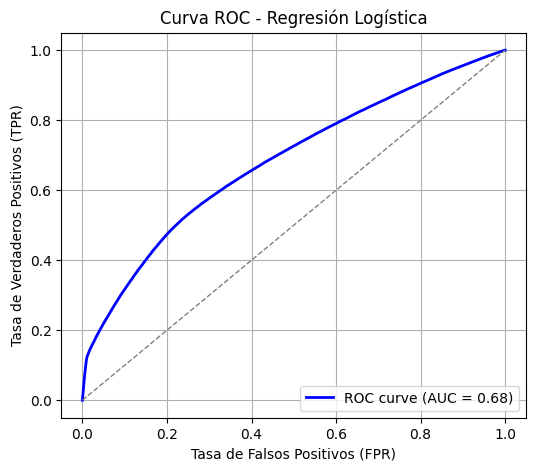

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)[:, 1]  # Probabilidades para ROC


print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred))
print("\n Reporte de clasificación:\n", classification_report(y_test, y_pred))

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Regresión Logística')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
# Predicciones sobre el conjunto de entrenamiento
y_pred_train = model.predict(x_train)
y_pred_train_proba = model.predict_proba(x_train)[:, 1]  # Probabilidades para ROC


print(" Exactitud (Accuracy):", accuracy_score(y_train, y_pred_train))
print("\n Matriz de confusión:\n", confusion_matrix(y_train, y_pred_train))
print("\n Reporte de clasificación:\n", classification_report(y_train, y_pred_train))

 Exactitud (Accuracy): 0.6668400249635947

 Matriz de confusión:
 [[771314 165323]
 [363172 286501]]

 Reporte de clasificación:
               precision    recall  f1-score   support

       False       0.68      0.82      0.74    936637
        True       0.63      0.44      0.52    649673

    accuracy                           0.67   1586310
   macro avg       0.66      0.63      0.63   1586310
weighted avg       0.66      0.67      0.65   1586310



In [ ]:
from xgboost import XGBClassifier

model1 = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

model1.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

 Exactitud (Accuracy): 0.6707736823193449

 Matriz de confusión:
 [[262415  49798]
 [124287  92270]]

 Reporte de clasificación:
               precision    recall  f1-score   support

       False       0.68      0.84      0.75    312213
        True       0.65      0.43      0.51    216557

    accuracy                           0.67    528770
   macro avg       0.66      0.63      0.63    528770
weighted avg       0.67      0.67      0.65    528770



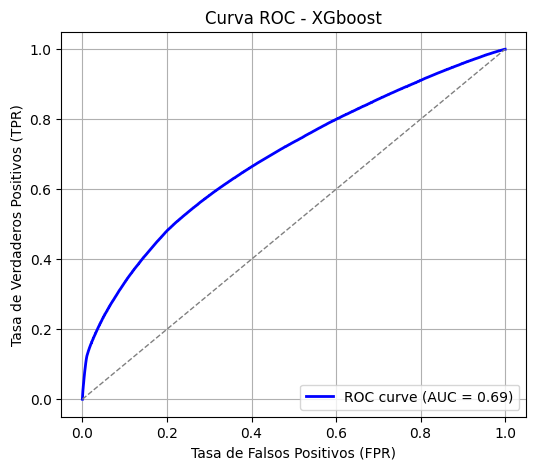

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred1 = model1.predict(x_test)
y_pred_proba1 = model1.predict_proba(x_test)[:, 1]  # Probabilidades para ROC


print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred1))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred1))
print("\n Reporte de clasificación:\n", classification_report(y_test, y_pred1))

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGboost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Variable": x.columns,
    "Importancia": model1.feature_importances_
})

importance.sort_values(
    "Importancia",
    ascending=False
).head(20)

,Variable,Importancia
55,tipo_entrada_LLAMADA DEL 911,0.333499
56,tipo_entrada_RADIO,0.264320
53,tipo_entrada_LLAMADA APP911,0.039698
51,tipo_entrada_CÁMARA,0.033252
10,tipo_incidente_c4_Cadáver,0.031383
23,incidente_c4_Incidente de tránsito,0.024529
21,incidente_c4_Ciclista,0.014422
38,alcaldia_inicio_CUAUHTEMOC,0.013961
57,tipo_entrada_REDES,0.013792
25,incidente_c4_Motociclista,0.012514


In [ ]:
pd.crosstab(
    df["tipo_entrada"],
    df["codigo_cierre"],
    normalize="index"
)

codigo_cierre,A,D,F,I,N
tipo_entrada,,,,,
APLICATIVOS,0.204484,0.223318,0.173991,0.273543,0.124664
BOTÓN DE AUXILIO,0.571666,0.372420,0.016905,0.005898,0.033111
CÁMARA,0.894373,0.070115,0.017847,0.006374,0.011291
LECTOR DE PLACAS,1.000000,0.000000,0.000000,0.000000,0.000000
LLAMADA APP911,0.255622,0.534637,0.018251,0.004538,0.186952
LLAMADA DEL 066,0.547347,0.214433,0.009145,0.008146,0.220930
LLAMADA DEL 911,0.311014,0.465331,0.098856,0.002868,0.121931
RADIO,0.889354,0.059161,0.014364,0.007227,0.029894
REDES,0.345179,0.265817,0.068207,0.004303,0.316494


In [ ]:
X_sin_tipo = x.drop(columns=[col for col in x.columns if col.startswith("tipo_entrada_")])

X=X_sin_tipo


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.25, random_state=42, stratify=y)

In [ ]:
X_train[["latitud", "longitud"]] = scaler.transform(
    X_train[["latitud", "longitud"]]
)

X_test[["latitud", "longitud"]] = scaler.transform(
    X_test[["latitud", "longitud"]]
)

In [ ]:
from xgboost import XGBClassifier

model1 = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

model1.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

 Exactitud (Accuracy): 0.6018949637838757

 Matriz de confusión:
 [[288281  23932]
 [186574  29983]]

 Reporte de clasificación:
               precision    recall  f1-score   support

       False       0.61      0.92      0.73    312213
        True       0.56      0.14      0.22    216557

    accuracy                           0.60    528770
   macro avg       0.58      0.53      0.48    528770
weighted avg       0.59      0.60      0.52    528770



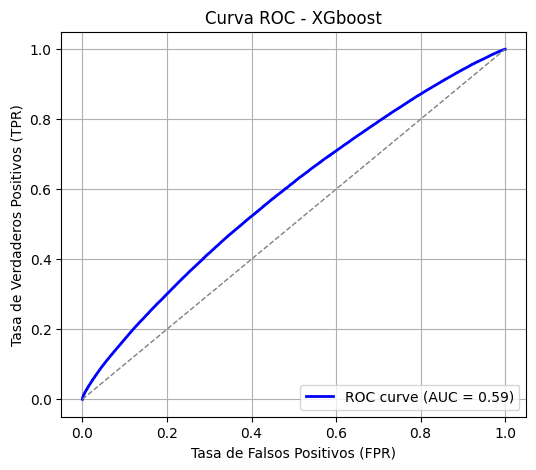

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred1 = model1.predict(X_test)
y_pred_proba1 = model1.predict_proba(X_test)[:, 1]  # Probabilidades para ROC


print(" Exactitud (Accuracy):", accuracy_score(y_test, y_pred1))
print("\n Matriz de confusión:\n", confusion_matrix(y_test, y_pred1))
print("\n Reporte de clasificación:\n", classification_report(y_test, y_pred1))

# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - XGboost')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
